In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

from sklearn.neighbors import KernelDensity
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler

import requests
import pandas as pd

[Descrizione del dataset sui Gamma Ray Bursts (GRBs)](https://user-web.icecube.wisc.edu/~grbweb_public/Variables.html)

The study of **Gamma Ray Bursts (GRBs)** is one of the astrophysical problems where clustering can be useful.

If you are able to identify two distinct classes, these are the so-called short GRBs and long GRBs. The long ones come from supernovae, while the short ones come from neutron star mergers.

In [2]:
# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str', unpack='True')

# Read headers
with open("Summary_table.txt", 'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

/tmp/ipython-input-1623729026.py:7: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str', unpack='True')


In [3]:
N_tot = len(data.T)
print(f"Total number of objects: {N_tot}")

Total number of objects: 8878


In [4]:
table = pd.DataFrame(data.T, columns=names)

In [5]:
table.sample(frac=0.001, random_state=0)

,GRB_name,GRB_name_Fermi,T0,ra,decl,pos_error,T90,T90_error,T90_start,fluence,fluence_error,redshift,'T100',GBM_located,mjd_(T0)
5076,GRB090408B,None,19:46:38.539,43.9800,26.6100,-999,-999,-999,-999,-999,-999,-999,-999,False,54929.82405716
7492,GRB951019A*,None,13:24:04.700,161.5000,-87.8167,1.800000,8.3840,1.4730,13:24:04.700,1.0586e-06,2.2099e-08,-999,8.3840,False,50009.55838773
5244,GRB080919B*,GRB080919790,18:57:34.977,219.5000,44.4000,8.154773,0.5120,0.4050,18:57:34.977,4.5867e-08,5.0626e-09,-999,0.5120,True,54728.78998816
8133,GRB930821A*,None,9:51:38.200,235.3250,-7.9333,2.780000,-999,-999,-999,-999,-999,-999,-999,False,49220.41085880
6479,GRB981105A*,None,1:25:54.496,171.0750,-52.4333,7.160000,44.9280,19.1910,1:25:54.496,6.4269e-08,9.5684e-09,-999,44.9280,False,51122.05965852
7552,GRB950804B*,None,12:36:16.124,186.6750,24.9333,1.460000,1.3010,0.0910,12:36:16.124,8.1408e-08,8.0443e-09,-999,1.3010,False,49933.52518662
379,GRB240805B,None,14:28:54,254.2153,18.3175,0.000621,-999,-999,-999,-999,-999,-999,-999,False,60527.60340278
7563,GRB950713A*,None,8:55:31.800,286.6750,30.0333,2.140000,85.2160,10.5460,8:55:31.800,4.8021e-06,1.1123e-07,-999,85.2160,False,49911.37189583
3585,GRB140226A,None,10:02:57,221.4917,15.0000,0.001667,-999,-999,-999,-999,-999,1.9800,-999,False,56714.41871528


In [6]:
vec_RA = np.array(table['ra'].astype(float))
vec_Dec = np.array(table['decl'].astype(float))
vec_z = np.array(table['redshift'].astype(float).replace(-999, np.nan))

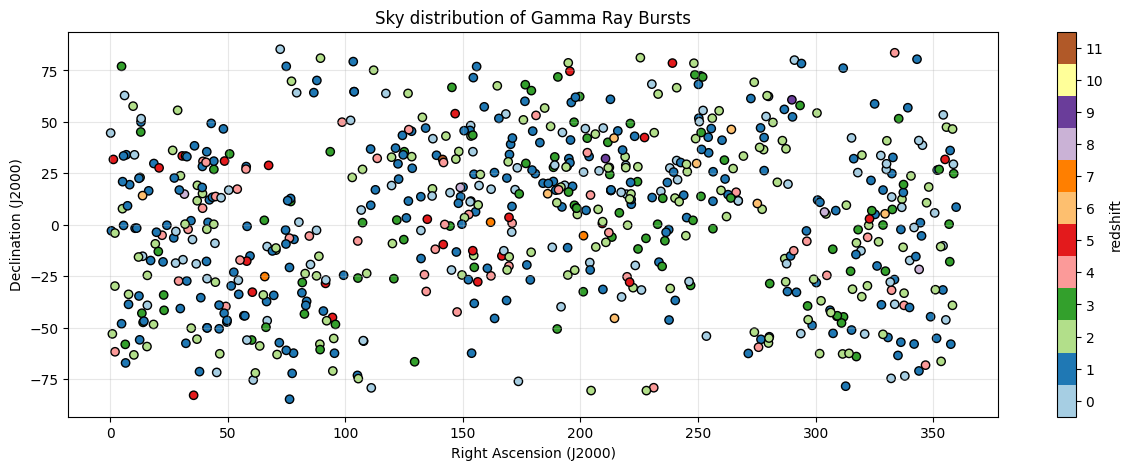

In [7]:
# Location in the sky
plt.figure(figsize=(15, 5))
plt.scatter(vec_RA[~np.isnan(vec_z)], vec_Dec[~np.isnan(vec_z)], c=vec_z[~np.isnan(vec_z)], cmap='Paired', marker="o", edgecolors="black")
plt.colorbar(label="redshift", ticks=range(12))
plt.clim(-0.5, 11.5)
plt.xlabel("Right Ascension (J2000)")
plt.ylabel("Declination (J2000)")
plt.title("Sky distribution of Gamma Ray Bursts")
plt.grid(alpha=0.3)
plt.show()

In [8]:
# Below there is a plot of the distribution of Gamma Ray Bursts, visualizing fluence [erg/cm^2] as a function of
# the time interval [s] during which 90% of the GRB photon counts are observed (starting at 5% and ending at 95%).

vec_fluence = np.array(table['fluence'].astype(float).replace(-999, np.nan))
vec_fluence_err = np.array(table['fluence_error'].astype(float).replace(-999, np.nan))
vec_T90 = np.array(table['T90'].astype(float).replace(-999, np.nan))
vec_T90_err = np.array(table['T90_error'].astype(float).replace(-999, np.nan))
cond = ~np.isnan(vec_T90) & ~np.isnan(vec_fluence) & (vec_T90>0) & (vec_fluence>0)

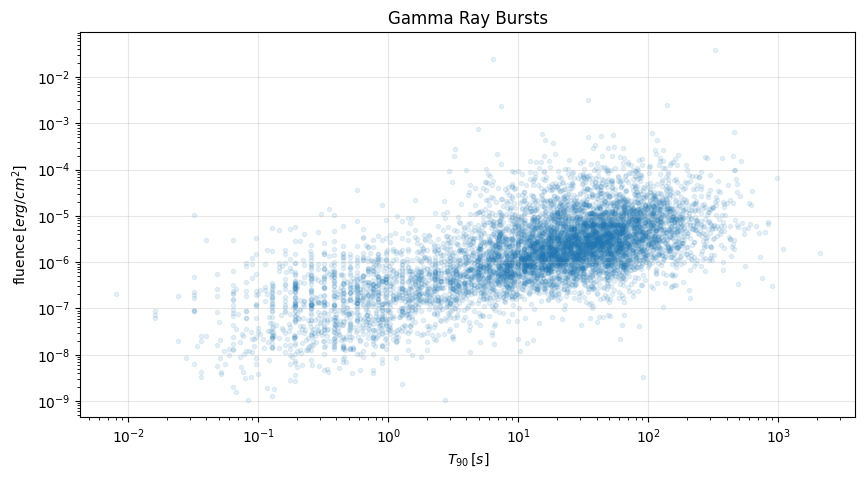

In [9]:
plt.figure(figsize=(10, 5))
plt.scatter(vec_T90[cond], vec_fluence[cond], marker='.', alpha=0.1)
plt.xlabel(r"$T_{90}\, [s]$")
plt.ylabel(r"$\text{fluence}\, [erg/cm^2]$")
plt.title("Gamma Ray Bursts")
plt.xscale("log")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.show()

In [10]:
sel_id = np.where(cond)[0]
sub_table = table.loc[sel_id]

In [11]:
sub_table[["T90", "T90_error", "fluence", "fluence_error"]]

,T90,T90_error,fluence,fluence_error
1,14.0800,1.1450,1.0960e-06,2.4607e-08
2,36.6090,0.3620,2.9633e-05,1.6409e-08
3,127.7470,0.3620,2.1091e-05,4.0240e-08
4,9.4080,0.1430,3.9707e-05,1.3751e-07
5,129.2830,0.9230,2.6062e-04,4.1459e-07
...,...,...,...,...
8873,430.0160,1.0940,1.3510e-06,6.3429e-08
8874,90.1760,0.2860,1.3277e-05,6.8674e-08
8875,3.1360,0.5900,2.4858e-08,1.0496e-08
8876,208.5760,1.1180,1.6510e-07,1.7015e-08


In [12]:
x = np.log10(vec_T90[cond])
y = np.log10(vec_fluence[cond])

# remember sklearn requires format (n_samples, n_features)
X = np.array([x, y]).T
print(X.shape)
X_1d = np.array([x]).T
print(X_1d.shape)
X_1d_fluence = np.array([y]).T
print(X_1d_fluence.shape)

(7581, 2)
(7581, 1)
(7581, 1)


In [13]:
# in addition define a KDE
def kde_sklearn(data, bandwidth, kernel, grid):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel = kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(grid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

**K-Means clustering**

In [14]:
# At first let's use the time data
clf_1d = KMeans(n_clusters=2, n_init='auto') # Try 2 clusters (short GRBs and long GRBs)
scaler_1d = StandardScaler()

clf_1d.fit(scaler_1d.fit_transform(X_1d))
centers_1d = scaler_1d.inverse_transform(clf_1d.cluster_centers_) # location of the clusters
labels_1d = clf_1d.predict(scaler_1d.transform(X_1d)) # labels for each of the points

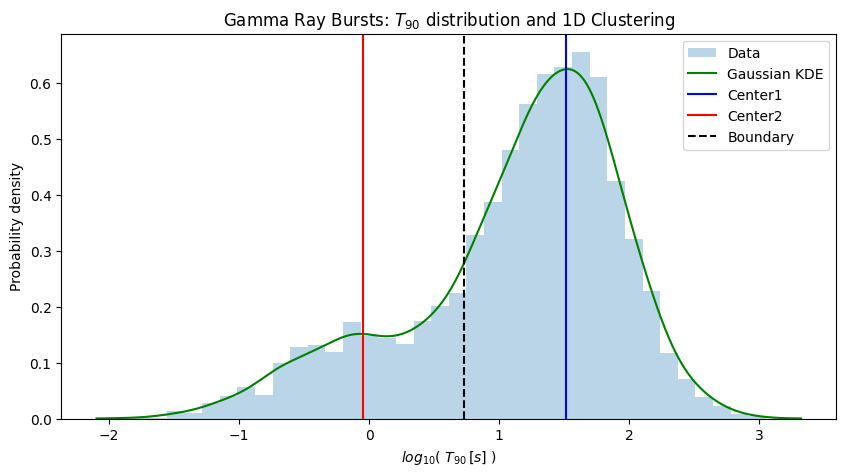

In [15]:
grid = np.linspace(x.min(), x.max(), 1000)
PDF = kde_sklearn(x, 0.15, "gaussian", grid)

plt.figure(figsize=(10, 5))
plt.hist(X_1d, bins=40, density=True, alpha=0.3, label="Data")
plt.plot(grid, PDF, "-g", label="Gaussian KDE")
plt.axvline(centers_1d[0], color="blue", label="Center1")
plt.axvline(centers_1d[1], color="red", label="Center2")
plt.axvline(np.mean(centers_1d), color="black", linestyle="--", label="Boundary")
plt.xlabel(r"$log_{10}$( $T_{90}\, [s]$ )")
plt.ylabel("Probability density")
plt.title("Gamma Ray Bursts: $T_{90}$ distribution and 1D Clustering")
plt.legend()
plt.show()

In [16]:
print("Time threshold = {:.1f} s".format(10**(np.mean(centers_1d))))

Time threshold = 5.4 s


In [17]:
# Now let's try again but with the fluence data
clf_1d_f = KMeans(n_clusters=2, n_init='auto') # Try 2 clusters (short GRBs and long GRBs)
scaler_1d_f = StandardScaler()

clf_1d_f.fit(scaler_1d_f.fit_transform(X_1d_fluence))
centers_1d_f = scaler_1d_f.inverse_transform(clf_1d_f.cluster_centers_) # location of the clusters
labels_1d_f = clf_1d_f.predict(scaler_1d_f.transform(X_1d_fluence)) # labels for each of the points

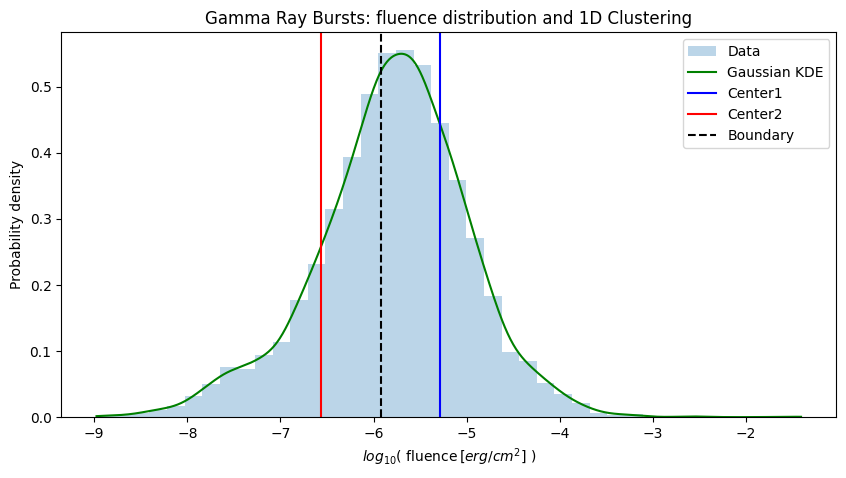

In [18]:
grid_f = np.linspace(y.min(), y.max(), 1000)
PDF_f = kde_sklearn(y, 0.15, "gaussian", grid_f)

plt.figure(figsize=(10, 5))
plt.hist(X_1d_fluence, bins=40, density=True, alpha=0.3, label="Data")
plt.plot(grid_f, PDF_f, "-g", label="Gaussian KDE")
plt.axvline(centers_1d_f[0], color="blue", label="Center1")
plt.axvline(centers_1d_f[1], color="red", label="Center2")
plt.axvline(np.mean(centers_1d_f), color="black", linestyle="--", label="Boundary")
plt.xlabel(r"$log_{10}$( $\text{fluence}\, [erg/cm^2]$ )")
plt.ylabel("Probability density")
plt.title("Gamma Ray Bursts: fluence distribution and 1D Clustering")
plt.legend()
plt.show()

In [19]:
print("Fluence threshold = {:.1e} erg/cm^2".format(10**(np.mean(centers_1d_f))))

Fluence threshold = 1.2e-06 erg/cm^2


In [20]:
# Now let's use both dimensions
clf = KMeans(n_clusters=2, n_init='auto') # Try 2 clusters (short GRBs and long GRBs)
scaler = StandardScaler()

clf.fit(scaler.fit_transform(X))
centers = scaler.inverse_transform(clf.cluster_centers_) # location of the clusters
labels = clf.predict(scaler.transform(X)) # labels for each of the points

In [21]:
# Centers
c1 = centers[0]
c2 = centers[1]

# Mean point
M = (c1 + c2) / 2
# Separation vector
v = c2 - c1
# Normal vector
n = np.array([-v[1], v[0]])

# Boundary line
t = np.linspace(-1.5, 1.5, 1000)
x_line = M[0] + t * n[0]
y_line = M[1] + t * n[1]

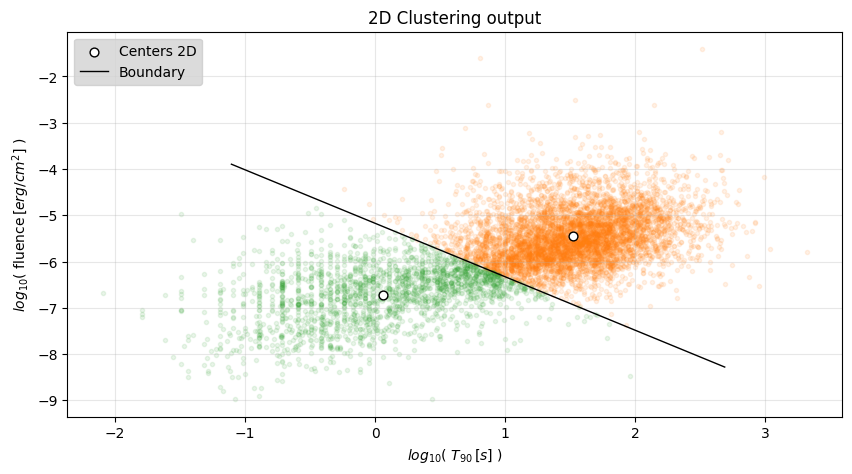

In [22]:
# plot the data color-coded by cluster id
colors = ['C1', 'C2']
plt.figure(figsize=(10, 5))
for ii in range(2):
    plt.scatter(X[labels==ii, 0], X[labels==ii, 1], color=colors[ii], alpha=0.1, marker='.')
plt.scatter(centers[:, 0], centers[:, 1], s=40, c='w', edgecolors='k', label="Centers 2D")
plt.plot(x_line, y_line, '-k', lw=1, label="Boundary")
plt.title('2D Clustering output');
plt.xlabel(r"$log_{10}$( $T_{90}\, [s]$ )")
plt.ylabel(r"$log_{10}$( $\text{fluence}\, [erg/cm^2]$ )")
plt.legend(facecolor='lightgray', loc="upper left")
plt.grid(alpha=0.3)
plt.show()

- **Long GRBs** tend to be brighter and longer, clustering at higher fluence values and higher burst duration values (top right datapoints).

- **Short GRBs** tend to be less energetic and shorter, clustering at lower fluence values and lower burst duration values (bottom left datapoints).

**Mean-Shift clustering**

In [23]:
# scale time data for a better fit
scaler_1d = StandardScaler()
std_X_1d = scaler_1d.fit_transform(X_1d)

# estimate bandwidth and clusters
bandwidth_1d = estimate_bandwidth(std_X_1d, quantile=0.2)
ms_1d = MeanShift(bandwidth=bandwidth_1d, bin_seeding=True, cluster_all=True)
ms_1d.fit(std_X_1d)
ms_1d_labels = ms_1d.labels_
ms_1d_centers = scaler_1d.inverse_transform(ms_1d.cluster_centers_)

In [24]:
labels_unique_1d = np.unique(ms_1d_labels)
n_clusters_1d = len(labels_unique_1d[labels_unique_1d >= 0])
print(labels_unique_1d)
print("{:.2f}".format(bandwidth_1d))
print("number of estimated clusters :", n_clusters_1d)

[0 1]
0.45
number of estimated clusters : 2


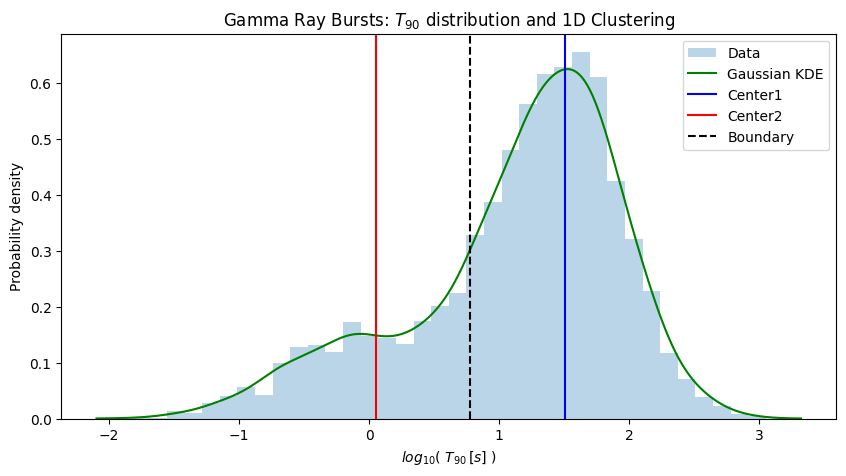

In [25]:
plt.figure(figsize=(10, 5))
plt.hist(X_1d, bins=40, density=True, alpha=0.3, label="Data")
plt.plot(grid, PDF, "-g", label="Gaussian KDE")
plt.axvline(ms_1d_centers[0], color="blue", label="Center1")
plt.axvline(ms_1d_centers[1], color="red", label="Center2")
plt.axvline(np.mean(ms_1d_centers), color="black", linestyle="--", label="Boundary")
plt.xlabel(r"$log_{10}$( $T_{90}\, [s]$ )")
plt.ylabel("Probability density")
plt.title("Gamma Ray Bursts: $T_{90}$ distribution and 1D Clustering")
plt.legend()
plt.show()

In [26]:
print("Time threshold = {:.1f} s".format(10**(np.mean(ms_1d_centers))))

Time threshold = 6.0 s


In [27]:
# scale data for a better fit
scaler = StandardScaler()
std_X = scaler.fit_transform(X)

# estimate bandwidth and clusters
# bandwidth = estimate_bandwidth(std_X, quantile=0.1)
bandwidth = 0.5
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True, cluster_all=True)
ms.fit(std_X)
ms_labels = ms.labels_
ms_centers = scaler.inverse_transform(ms.cluster_centers_)

In [28]:
labels_unique = np.unique(ms_labels)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)

[ 0  1  2  3  4  5  6  7  8  9 10 11]
0.5
number of estimated clusters : 12


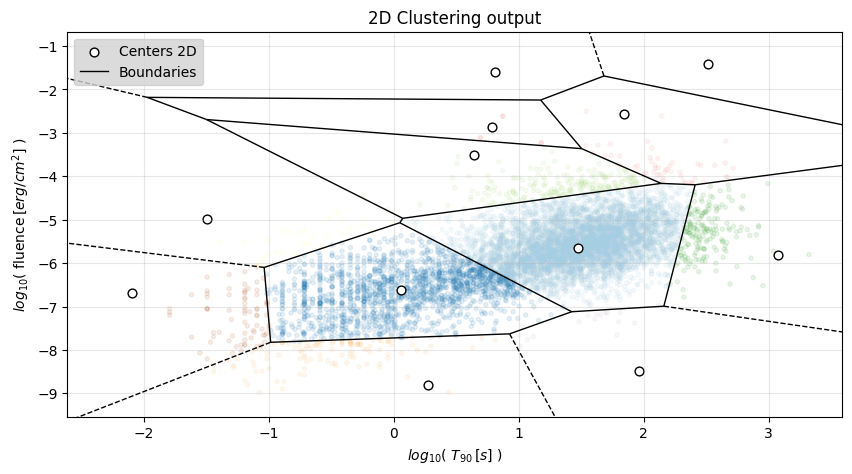

In [29]:
# plot the data color-coded by cluster id
from scipy.spatial import Voronoi, voronoi_plot_2d
from matplotlib.lines import Line2D

vor = Voronoi(ms_centers)
fig, ax = plt.subplots(figsize=(10, 5))

voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='black', line_width=1, point_size=0) # Boundaries
ax.scatter(X[:, 0], X[:, 1], c=ms_labels, cmap="Paired", alpha=0.1, marker='.') # Datapoints
ax.scatter(ms_centers[:, 0], ms_centers[:, 1], s=40, c='w', edgecolors='k', label="Centers 2D") # Centers
custom_line = Line2D([0], [0], color='black', linewidth=1, linestyle='-') # Phantom object for boundaries label
plt_handles, plt_labels = plt.gca().get_legend_handles_labels()
plt_handles.append(custom_line)
plt_labels.append('Boundaries')

ax.set_title('2D Clustering output');
ax.set_xlabel(r"$log_{10}$( $T_{90}\, [s]$ )")
ax.set_ylabel(r"$log_{10}$( $\text{fluence}\, [erg/cm^2]$ )")
ax.legend(facecolor='lightgray', loc="upper left", handles=plt_handles, labels=plt_labels)
plt.grid(alpha=0.3)
plt.show()

Mean-Shift clustering can be sensitive to outliers, because it moves points towards nearby dense regions, and outliers (isolated points) can sometimes wrongly start their own small clusters.

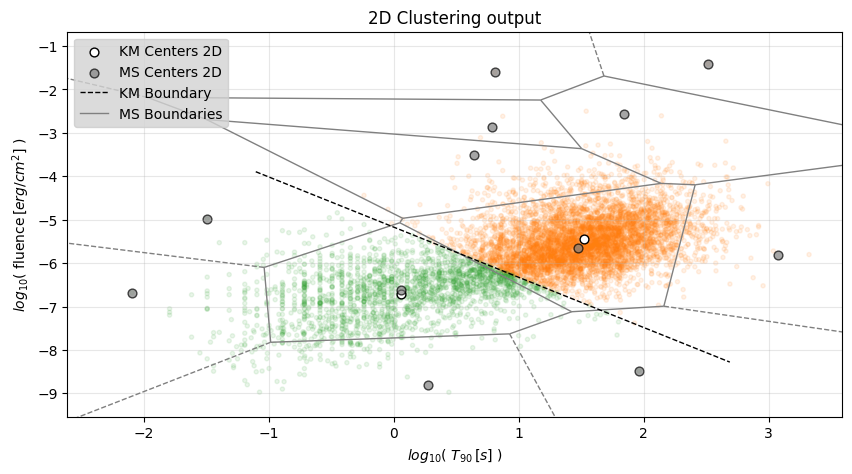

In [30]:
# Visualizing similarities and differences into the results obtained with the two clustering algorithms
from matplotlib.colors import ListedColormap

my_cmap = ListedColormap(colors, name="custom_cmap")
fig, ax = plt.subplots(figsize=(10, 5))

voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='gray', line_width=1, point_size=0) # Mean-Shift Boundaries
ax.scatter(X[:, 0], X[:, 1], c=labels, cmap=my_cmap, alpha=0.1, marker='.') # Datapoints
ax.scatter(centers[:, 0], centers[:, 1], s=40, c='white', edgecolors='k', label="KM Centers 2D") # K-Means Centers
ax.scatter(ms_centers[:, 0], ms_centers[:, 1], s=40, c='gray', edgecolors='k', alpha=0.7, label="MS Centers 2D") # Mean-Shift Centers
ax.plot(x_line, y_line, color='black', lw=1, linestyle="--", label="KM Boundary") # K-Means Boundary
custom_line = Line2D([0], [0], color='gray', linewidth=1, linestyle='-') # Phantom object for boundaries label
plt_handles, plt_labels = plt.gca().get_legend_handles_labels()
plt_handles.append(custom_line)
plt_labels.append('MS Boundaries')

ax.set_title('2D Clustering output');
ax.set_xlabel(r"$log_{10}$( $T_{90}\, [s]$ )")
ax.set_ylabel(r"$log_{10}$( $\text{fluence}\, [erg/cm^2]$ )")
ax.legend(facecolor='lightgray', loc="upper left", handles=plt_handles, labels=plt_labels)
plt.grid(alpha=0.3)
plt.show()

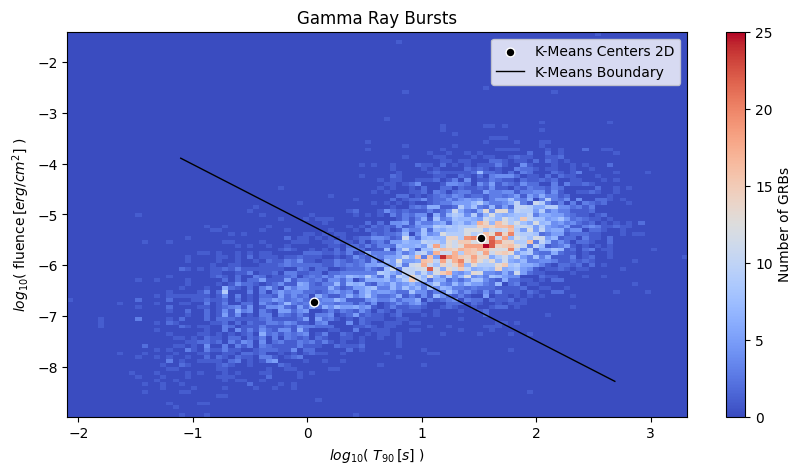

In [31]:
# Visualizing if all GRBs are equally likely to be observed
H, xedges, yedges = np.histogram2d(X[:,0], X[:,1], 100)
plt.figure(figsize=(10, 5))
plt.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='coolwarm')
plt.colorbar(label="Number of GRBs")
plt.scatter(centers[:, 0], centers[:, 1], s=40, c='k', edgecolors='w', label="K-Means Centers 2D")
plt.plot(x_line, y_line, '-k', lw=1, label="K-Means Boundary")
plt.title("Gamma Ray Bursts")
plt.xlabel(r"$log_{10}$( $T_{90}\, [s]$ )")
plt.ylabel(r"$log_{10}$( $\text{fluence}\, [erg/cm^2]$ )")
plt.legend()
plt.show()

**Relevant physical questions that have been taken into account so far:**

1. Does the distribution contain different sub-populations? How many?

Yes, we can observe two different classes of GRBs in the fluence vs burst duration plot.

2. What's the threshold between the classes?

The inferred 1D threshold is $T_{90}=5-6\,s$, but in 2D the boundary isn’t strictly vertical because GRBs are not separated purely by duration: their fluence also plays an important role.

3. If you try two clustering methods, do you get more or less the same?

Yes, if we ignore outliers effects into the results of Mean-Shift clustering we can state that the classes we found are more or less the same.

4. How do methods respond to outliers?

Mean-Shift clustering can be sensitive to outliers, because it moves points towards nearby dense regions, and outliers (isolated points) can sometimes wrongly start their own small clusters.

5. What variable(s) shows the multi-modality more evidently?

In 1D, only the burst duration distribution shows a perceptible bi-modality.

6. Are all GRBs equally likely to be observed?

We can notice in the last plot that long GRBs are more common than short GRBs.